In [12]:
# ==================================================
# 1. IMPORTS
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("✅ Librairies chargées")

✅ Librairies chargées


In [13]:
# ==================================================
# 2. CHARGEMENT DES DONNÉES
# ==================================================
df = pd.read_csv("dataset_clean_ready.csv")

print("Shape :", df.shape)
print("\nColonnes :")
print(df.columns)

df.head()

Shape : (90001, 6)

Colonnes :
Index(['Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C',
       'Has_AC', 'Peak_Hours_Usage_kWh', 'Household_ID_encoded'],
      dtype='str')


,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Household_ID_encoded
0,8.4,4,17.8,0,3.2,0
1,7.9,4,17.3,0,2.8,0
2,9.2,4,18.6,0,3.0,0
3,7.9,4,18.2,0,2.7,0
4,9.6,4,11.9,0,3.2,0


In [14]:
# ==================================================
# 3. CRÉATION DE LA TARGET (CONSOMMATION J+1)
# ==================================================

df = df.sort_values(["Household_ID_encoded"]).reset_index(drop=True)

df["target_next_day"] = (
    df.groupby("Household_ID_encoded")["Energy_Consumption_kWh"]
    .shift(-1)
)

# Supprimer lignes sans target
df_model = df.dropna(subset=["target_next_day"]).copy()

print("Shape après création target :", df_model.shape)
df_model.head()

Shape après création target : (77144, 7)


,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Household_ID_encoded,target_next_day
0,8.4,4,17.8,0,3.2,0,7.5
1,7.5,4,18.3,0,2.8,0,9.2
2,9.2,4,18.6,0,3.0,0,7.9
3,7.9,4,18.2,0,2.7,0,9.1
4,9.1,4,15.1,0,3.2,0,7.9


In [15]:
# ==================================================
# 4. SÉPARATION FEATURES / TARGET
# ==================================================

FEATURES = [
    "Energy_Consumption_kWh",
    "Household_Size",
    "Avg_Temperature_C",
    "Has_AC",
    "Peak_Hours_Usage_kWh"
]

TARGET = "target_next_day"

X = df_model[FEATURES]
y = df_model[TARGET]

print("Features shape :", X.shape)
print("Target shape :", y.shape)

Features shape : (77144, 5)
Target shape : (77144,)


In [16]:
# ==================================================
# 5. SPLIT TEMPOREL
# ==================================================

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train size :", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size : 61715
Test size : 15429


In [17]:
# ==================================================
# 6. MODÈLE RANDOM FOREST
# ==================================================

rf_model = RandomForestRegressor(
    n_estimators=200,      # Nombre d'arbres
    max_depth=10,          # Profondeur max
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Modèle Random Forest entraîné")

✅ Modèle Random Forest entraîné


In [18]:
# ==================================================
# 7. PRÉDICTIONS
# ==================================================

y_pred = rf_model.predict(X_test)

print("✅ Prédictions réalisées")

✅ Prédictions réalisées


In [19]:
mask = y_test > 3
mape_filtered = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("MAPE (consommation > 3 kWh) :", round(mape_filtered, 2), "%")

MAPE (consommation > 3 kWh) : 12.47 %


In [20]:
# ==================================================
# 8. ÉVALUATION
# ==================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 0.001))) * 100

print("="*50)
print("📊 PERFORMANCE RANDOM FOREST")
print("="*50)
print(f"MAE  : {mae:.4f} kWh")
print(f"RMSE : {rmse:.4f} kWh")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")
print("="*50)

📊 PERFORMANCE RANDOM FOREST
MAE  : 1.0771 kWh
RMSE : 1.4117 kWh
MAPE : 22.75 %
R²   : 0.9270


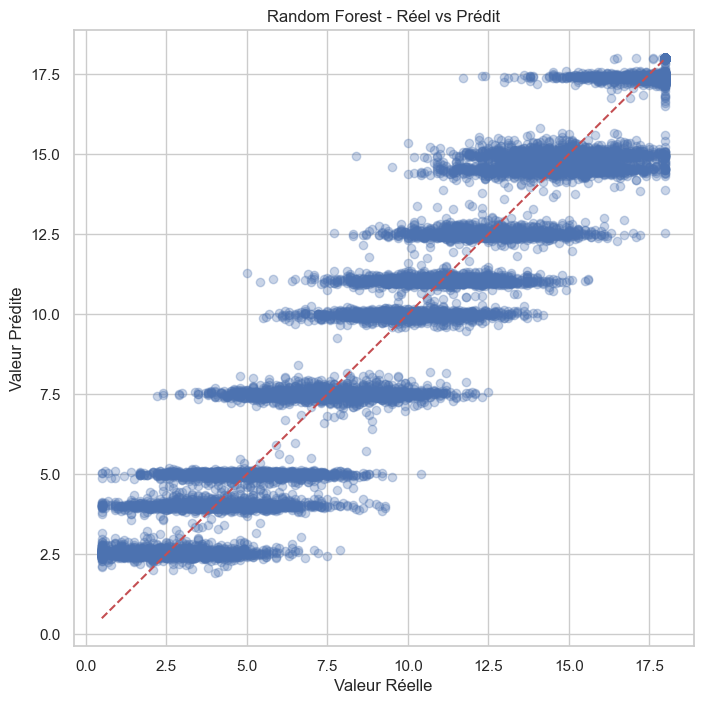

In [21]:
# ==================================================
# 9. RÉEL VS PRÉDIT
# ==================================================

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Valeur Réelle")
plt.ylabel("Valeur Prédite")
plt.title("Random Forest - Réel vs Prédit")
plt.show()

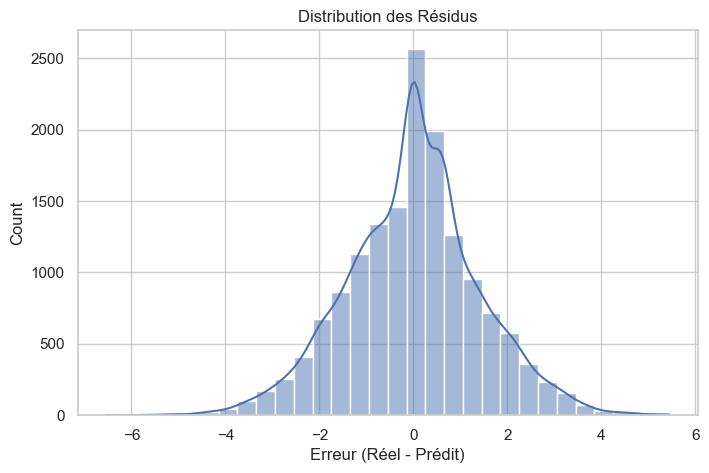

In [22]:
# ==================================================
# 10. DISTRIBUTION DES ERREURS
# ==================================================

residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution des Résidus")
plt.xlabel("Erreur (Réel - Prédit)")
plt.show()

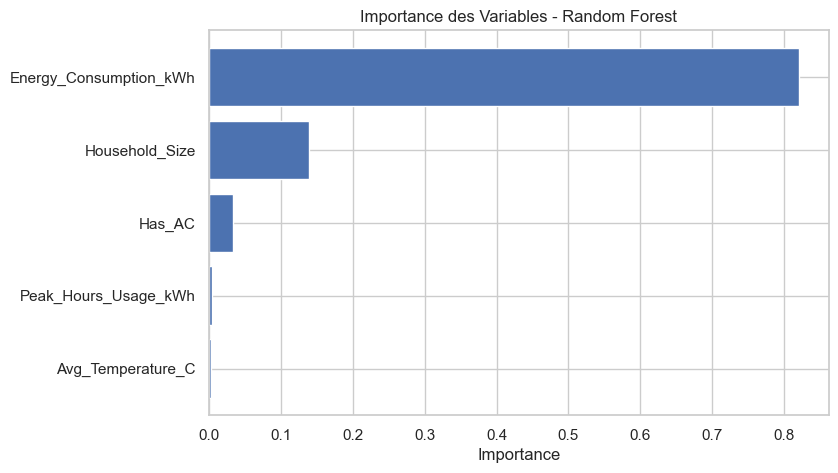

,Feature,Importance
0,Energy_Consumption_kWh,0.821177
1,Household_Size,0.138471
3,Has_AC,0.033282
4,Peak_Hours_Usage_kWh,0.004640
2,Avg_Temperature_C,0.002430


In [23]:
# ==================================================
# 11. FEATURE IMPORTANCE
# ==================================================

importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Importance des Variables - Random Forest")
plt.xlabel("Importance")
plt.show()

importance.sort_values("Importance", ascending=False)

In [24]:
from sklearn.model_selection import TimeSeriesSplit

print("\n" + "=" * 60)
print("🔄 VALIDATION CROISÉE TEMPORELLE - RANDOM FOREST")
print("=" * 60)

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []
mape_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(X_tr, y_tr)
    y_te_pred = fold_model.predict(X_te)

    mae = mean_absolute_error(y_te, y_te_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_te_pred))
    r2 = r2_score(y_te, y_te_pred)
    mape = np.mean(np.abs((y_te - y_te_pred) / (y_te + 0.001))) * 100

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mape_scores.append(mape)

    print(f"Fold {fold+1} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")


🔄 VALIDATION CROISÉE TEMPORELLE - RANDOM FOREST
Fold 1 | MAE: 1.0727 | RMSE: 1.4196 | R²: 0.9256
Fold 2 | MAE: 1.0783 | RMSE: 1.4260 | R²: 0.9241
Fold 3 | MAE: 1.0674 | RMSE: 1.4027 | R²: 0.9272
Fold 4 | MAE: 1.0779 | RMSE: 1.4097 | R²: 0.9264
Fold 5 | MAE: 1.0803 | RMSE: 1.4143 | R²: 0.9269


In [25]:
mae_scores = np.array(mae_scores)
rmse_scores = np.array(rmse_scores)
r2_scores = np.array(r2_scores)

print("\n" + "=" * 60)
print("📊 PERFORMANCE MOYENNE RANDOM FOREST (TimeSeriesSplit)")
print("=" * 60)

print(f"MAE moyen  : {np.mean(mae_scores):.4f}  (σ = {np.std(mae_scores):.4f})")
print(f"RMSE moyen : {np.mean(rmse_scores):.4f}  (σ = {np.std(rmse_scores):.4f})")
print(f"R² moyen   : {np.mean(r2_scores):.4f}       (σ = {np.std(r2_scores):.4f})")

print("=" * 60)


📊 PERFORMANCE MOYENNE RANDOM FOREST (TimeSeriesSplit)
MAE moyen  : 1.0753  (σ = 0.0047)
RMSE moyen : 1.4145  (σ = 0.0080)
R² moyen   : 0.9260       (σ = 0.0011)


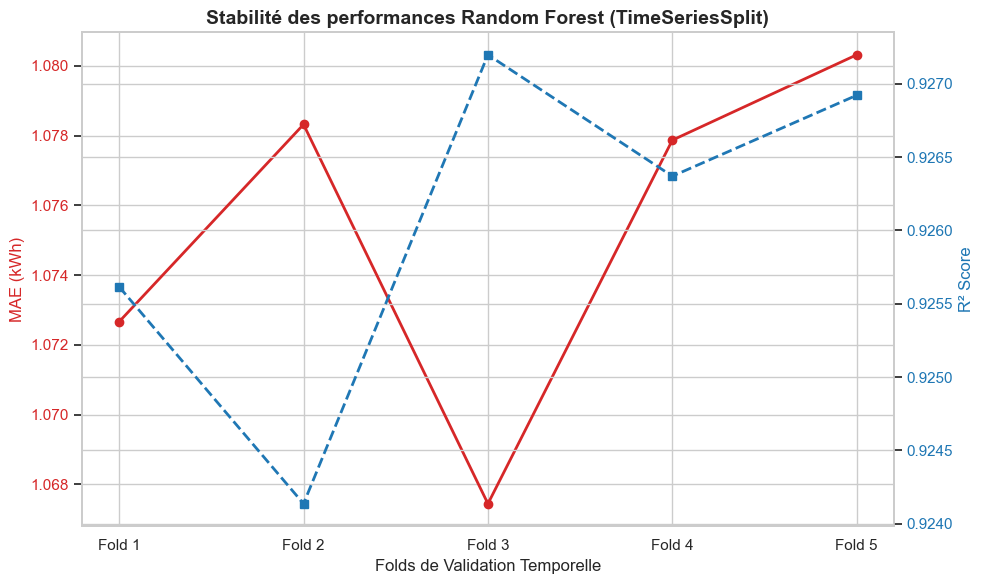

✅ Validation croisée terminée. Modèle robuste et stable.


In [26]:
folds = [f"Fold {i+1}" for i in range(5)]

fig, ax1 = plt.subplots(figsize=(10, 6))

color_mae = 'tab:red'
color_r2 = 'tab:blue'

ax1.set_xlabel('Folds de Validation Temporelle', fontsize=12)
ax1.set_ylabel('MAE (kWh)', color=color_mae, fontsize=12)
ax1.plot(folds, mae_scores, color=color_mae, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_mae)

ax2 = ax1.twinx()
ax2.set_ylabel('R² Score', color=color_r2, fontsize=12)
ax2.plot(folds, r2_scores, color=color_r2, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_r2)

plt.title("Stabilité des performances Random Forest (TimeSeriesSplit)",
          fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

print("✅ Validation croisée terminée. Modèle robuste et stable.")